# 55%. Eso es lo que queda.

De 274 hallazgos en ciencias sociales, la mitad no sobrevive cuando alguien intenta replicarlos.

---

📄 **Paper:** Investigating the replicability of the social and behavioural sciences  
🔬 **Journal:** Nature (2025) — DOI: [10.1038/s41586-025-10078-y](https://doi.org/10.1038/s41586-025-10078-y)  
📊 **Datos:** [OSF — Analyst package](https://doi.org/10.17605/OSF.IO/BZFGY) (RData, MIT)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-05-replicabilidad-ciencias-sociales/notebook.ipynb)

**Video:** [Pendiente]

## El proyecto SCORE

¿Cuánto de lo que sabemos en ciencias sociales es verdad? Un equipo de cientos de investigadores decidió averiguarlo. Seleccionaron 274 claims positivos de 164 papers publicados entre 2009 y 2018 en 54 revistas top — psicología, economía, sociología, ciencia política — y los replicaron con muestras grandes (poder estadístico mediano del 99,6%).

No fue un ataque: fue una auditoría. Cada réplica usó los materiales originales, fue revisada por pares, y siguió un protocolo estandarizado. El resultado es una de las radiografías más grandes de la replicabilidad en ciencias sociales.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_P = 0.05             # Umbral de significancia
FUENTE = 'Fuente: Protzko et al. (2025), Nature | Datos: OSF analyst package (MIT)'
COLOR_REPLICADO = '#2563EB'   # Azul CaM
COLOR_NO_REPLICADO = '#DC2626'  # Rojo
COLOR_SECUNDARIO = '#059669'   # Emerald
COLOR_REFERENCIA = '#D97706'   # Amber
COLOR_CONTEXTO = '#BBBBBB'     # Gris

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, urllib.request

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Datos base URL (para Colab)
BASE = f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/{os.path.basename(os.getcwd())}' \
    if os.path.exists('datos') else \
    'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-05-replicabilidad-ciencias-sociales'

def load(name):
    try:
        return pd.read_csv(f'datos/{name}')
    except FileNotFoundError:
        return pd.read_csv(f'{BASE}/datos/{name}')

scatter = load('efecto_original_vs_replica.csv')
campos = load('replicabilidad_por_campo.csv')
metodos = load('metodos_evaluacion_replica.csv')

print(f'Datos cargados:')
print(f'  274 claims replicados → {len(scatter)} filas')
print(f'  {len(campos)} campos académicos')
print(f'  {len(metodos)} métodos de evaluación')
print(f'  Claims replicados: {scatter["repli_score_criteria_met"].sum():.0f}/274 ({scatter["repli_score_criteria_met"].mean()*100:.1f}%)')

Datos cargados:
  274 claims replicados → 274 filas
  10 campos académicos
  12 métodos de evaluación
  Claims replicados: 151/274 (55.1%)


## Cada punto es un hallazgo científico

Aquí está.

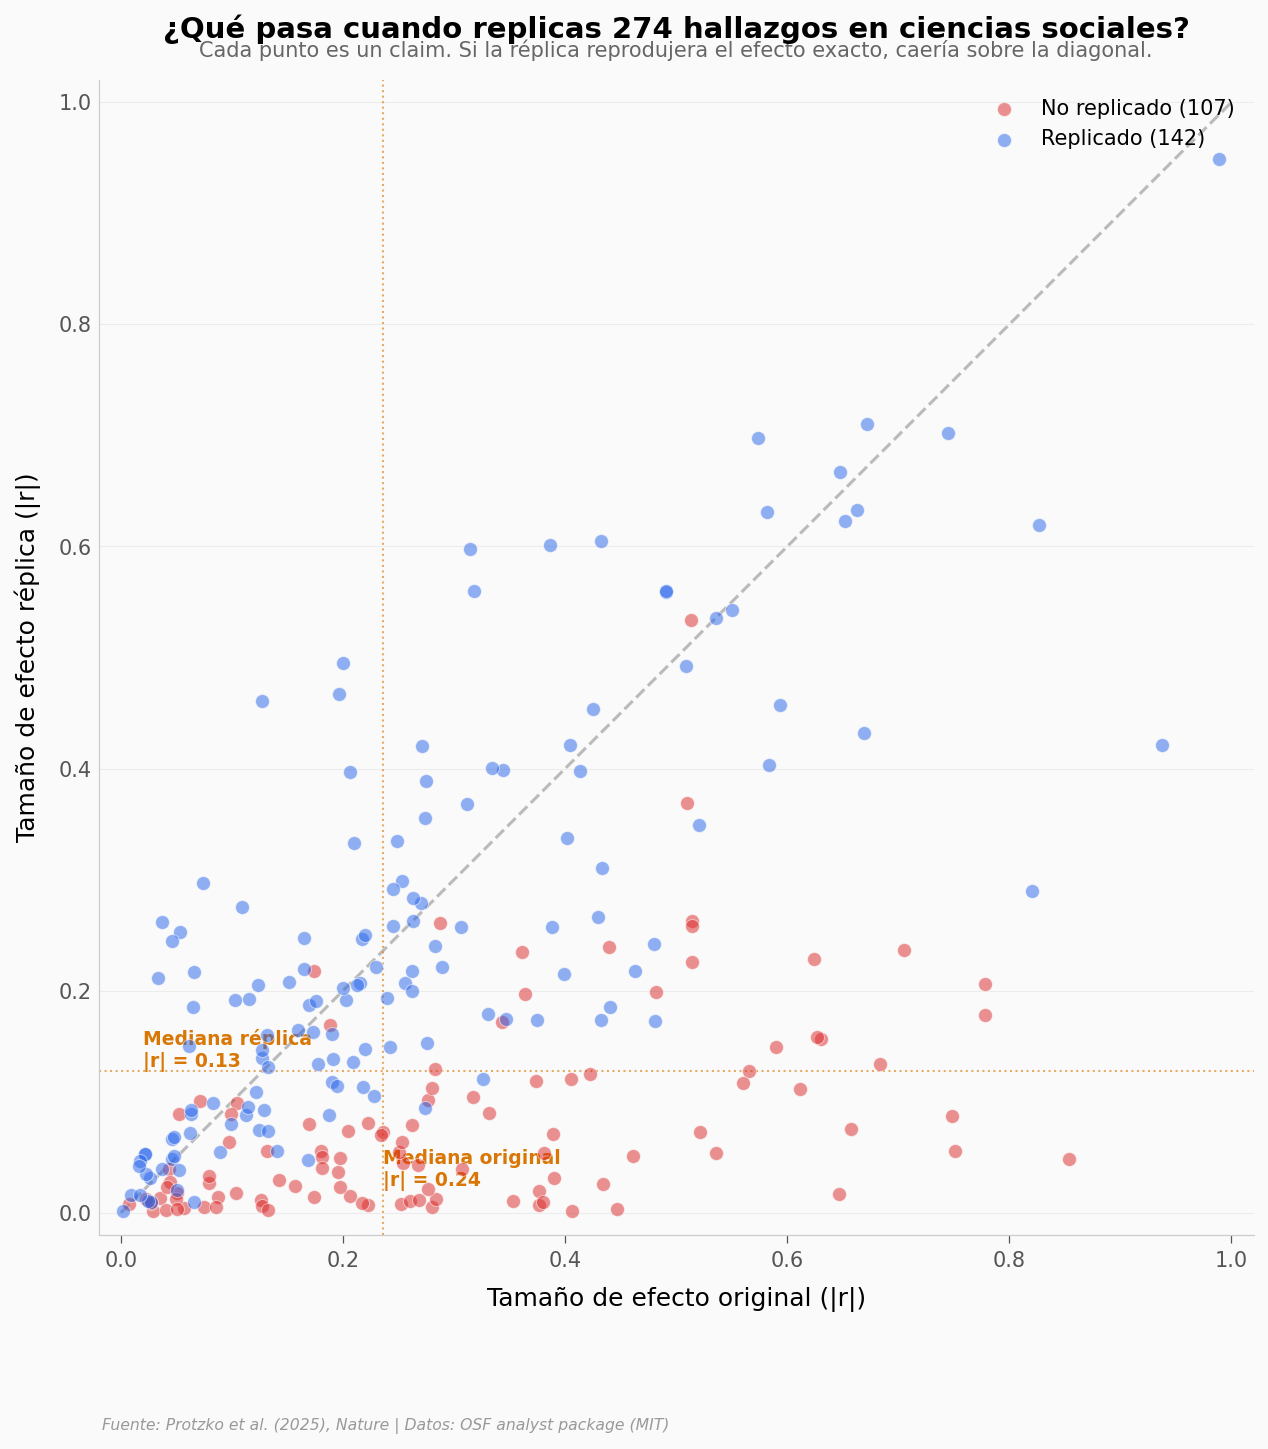

In [2]:
# Gráfica hero: efecto original vs efecto replicado
df = scatter.dropna(subset=['abs_orig_r', 'abs_repli_r']).copy()

fig, ax = plt.subplots(figsize=(10, 10))

# Diagonal: lo que esperaríamos si todo se replicara
ax.plot([0, 1], [0, 1], color=COLOR_CONTEXTO, linewidth=1.5, linestyle='--', zorder=1)

# Puntos coloreados por éxito de replicación
rep = df[df['repli_score_criteria_met'] == True]
norep = df[df['repli_score_criteria_met'] == False]

ax.scatter(norep['abs_orig_r'], norep['abs_repli_r'],
           color=COLOR_NO_REPLICADO, s=45, alpha=0.5,
           edgecolors='white', linewidths=0.5, zorder=4,
           label=f'No replicado ({len(norep)})')
ax.scatter(rep['abs_orig_r'], rep['abs_repli_r'],
           color=COLOR_REPLICADO, s=45, alpha=0.5,
           edgecolors='white', linewidths=0.5, zorder=5,
           label=f'Replicado ({len(rep)})')

# Medianas
med_orig = df['abs_orig_r'].median()
med_repli = df['abs_repli_r'].median()
ax.axvline(med_orig, color=COLOR_REFERENCIA, linewidth=1, linestyle=':', alpha=0.6, zorder=2)
ax.axhline(med_repli, color=COLOR_REFERENCIA, linewidth=1, linestyle=':', alpha=0.6, zorder=2)

ax.annotate(f'Mediana original\n|r| = {med_orig:.2f}',
            xy=(med_orig, 0.02), fontsize=9, color=COLOR_REFERENCIA,
            ha='left', va='bottom', fontweight='bold')
ax.annotate(f'Mediana réplica\n|r| = {med_repli:.2f}',
            xy=(0.02, med_repli), fontsize=9, color=COLOR_REFERENCIA,
            ha='left', va='bottom', fontweight='bold')

ax.set_xlabel('Tamaño de efecto original (|r|)', fontsize=12)
ax.set_ylabel('Tamaño de efecto réplica (|r|)', fontsize=12)
ax.set_title('¿Qué pasa cuando replicas 274 hallazgos en ciencias sociales?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto es un claim. Si la réplica reprodujera el efecto exacto, caería sobre la diagonal.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

La mayoría de los puntos caen **por debajo** de la diagonal. Eso significa que los efectos se encogen cuando alguien los replica.

El efecto mediano original era |r| = 0,24. En la réplica baja a 0,13 — casi la mitad. Y esto usando réplicas de alta potencia estadística (mediana 99,6%): no es que les faltara muestra.

De los 249 claims con datos emparejados, en el 41% el efecto replicado se redujo a **menos de la mitad**. Y uno de cada cinco (22,5%) quedó por debajo del **25%** del original.

Los puntos rojos (no replicados) se concentran donde los efectos originales eran medianos o pequeños — precisamente donde la inflación estadística hace más daño.

## ¿En qué campo se replica mejor?

No todas las disciplinas están igual. La tasa varía entre el 43% y el 71% dependiendo del campo — aunque en algunos hay pocas réplicas para estar seguros.

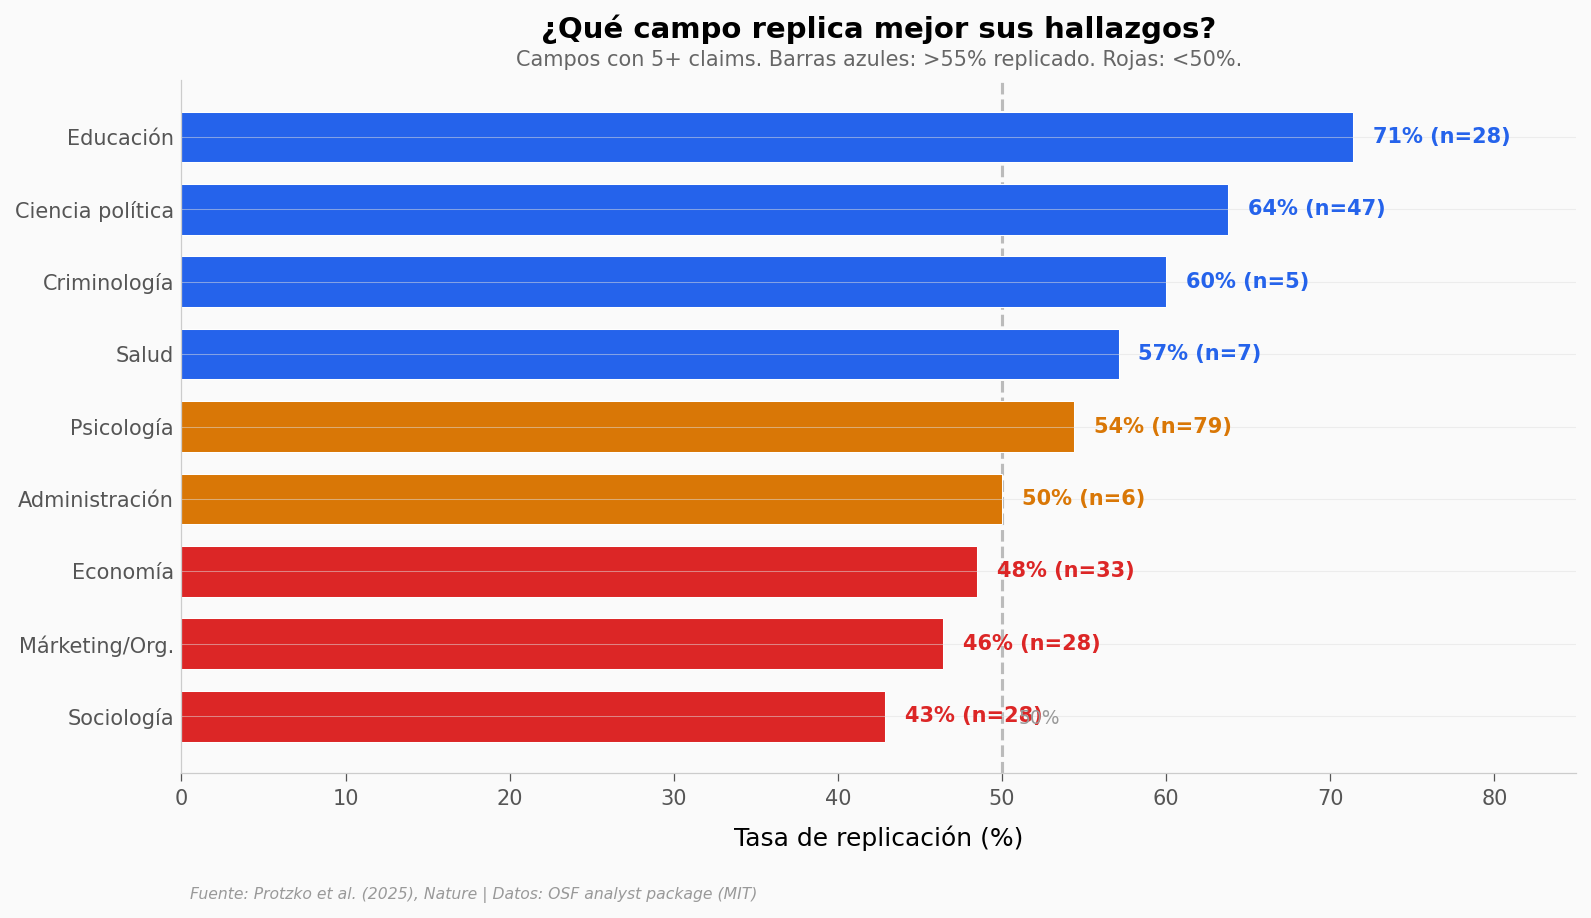

In [3]:
# Replicabilidad por campo (solo campos con n ≥ 5)
df_campos = campos[campos['n'] >= 5].sort_values('pct').copy()

# Traducción
trad = {
    'education': 'Educación', 'political science': 'Ciencia política',
    'criminology': 'Criminología', 'health': 'Salud',
    'psychology': 'Psicología', 'management': 'Administración',
    'economics': 'Economía', 'marketing/org behavior': 'Márketing/Org.',
    'sociology': 'Sociología', 'covid': 'COVID-19'
}
df_campos['field_es'] = df_campos['field'].map(trad)

fig, ax = plt.subplots(figsize=(12, 6))

colores = [COLOR_REPLICADO if p >= 55 else COLOR_NO_REPLICADO if p < 50 else COLOR_REFERENCIA
           for p in df_campos['pct']]

bars = ax.barh(df_campos['field_es'], df_campos['pct'],
               color=colores, edgecolor='white', linewidth=0.5, height=0.7)

# Etiquetas con n
for bar, (_, row) in zip(bars, df_campos.iterrows()):
    x = bar.get_width()
    ax.text(x + 1.2, bar.get_y() + bar.get_height()/2,
            f'{row["pct"]:.0f}% (n={int(row["n"])})',
            va='center', fontsize=10, fontweight='bold',
            color=bar.get_facecolor())

# Línea del 50%
ax.axvline(50, color=COLOR_CONTEXTO, linewidth=1.5, linestyle='--', zorder=0)
ax.text(51, -0.1, '50%', fontsize=9, color='#999999')

ax.set_xlabel('Tasa de replicación (%)', fontsize=12)
ax.set_xlim(0, 85)
ax.set_title('¿Qué campo replica mejor sus hallazgos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Campos con 5+ claims. Barras azules: >55% replicado. Rojas: <50%.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/replicabilidad_campo.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y si el problema no es la ciencia, sino la vara?

Aquí es donde se pone interesante. Los autores usaron **13 métodos distintos** para definir si una réplica "tuvo éxito" (12 disponibles en el analyst package público). Desde el más estricto (¿el efecto original cae dentro del intervalo de confianza de la réplica?) hasta el más generoso (¿el meta-análisis combinado sigue siendo significativo?).

La diferencia es brutal.

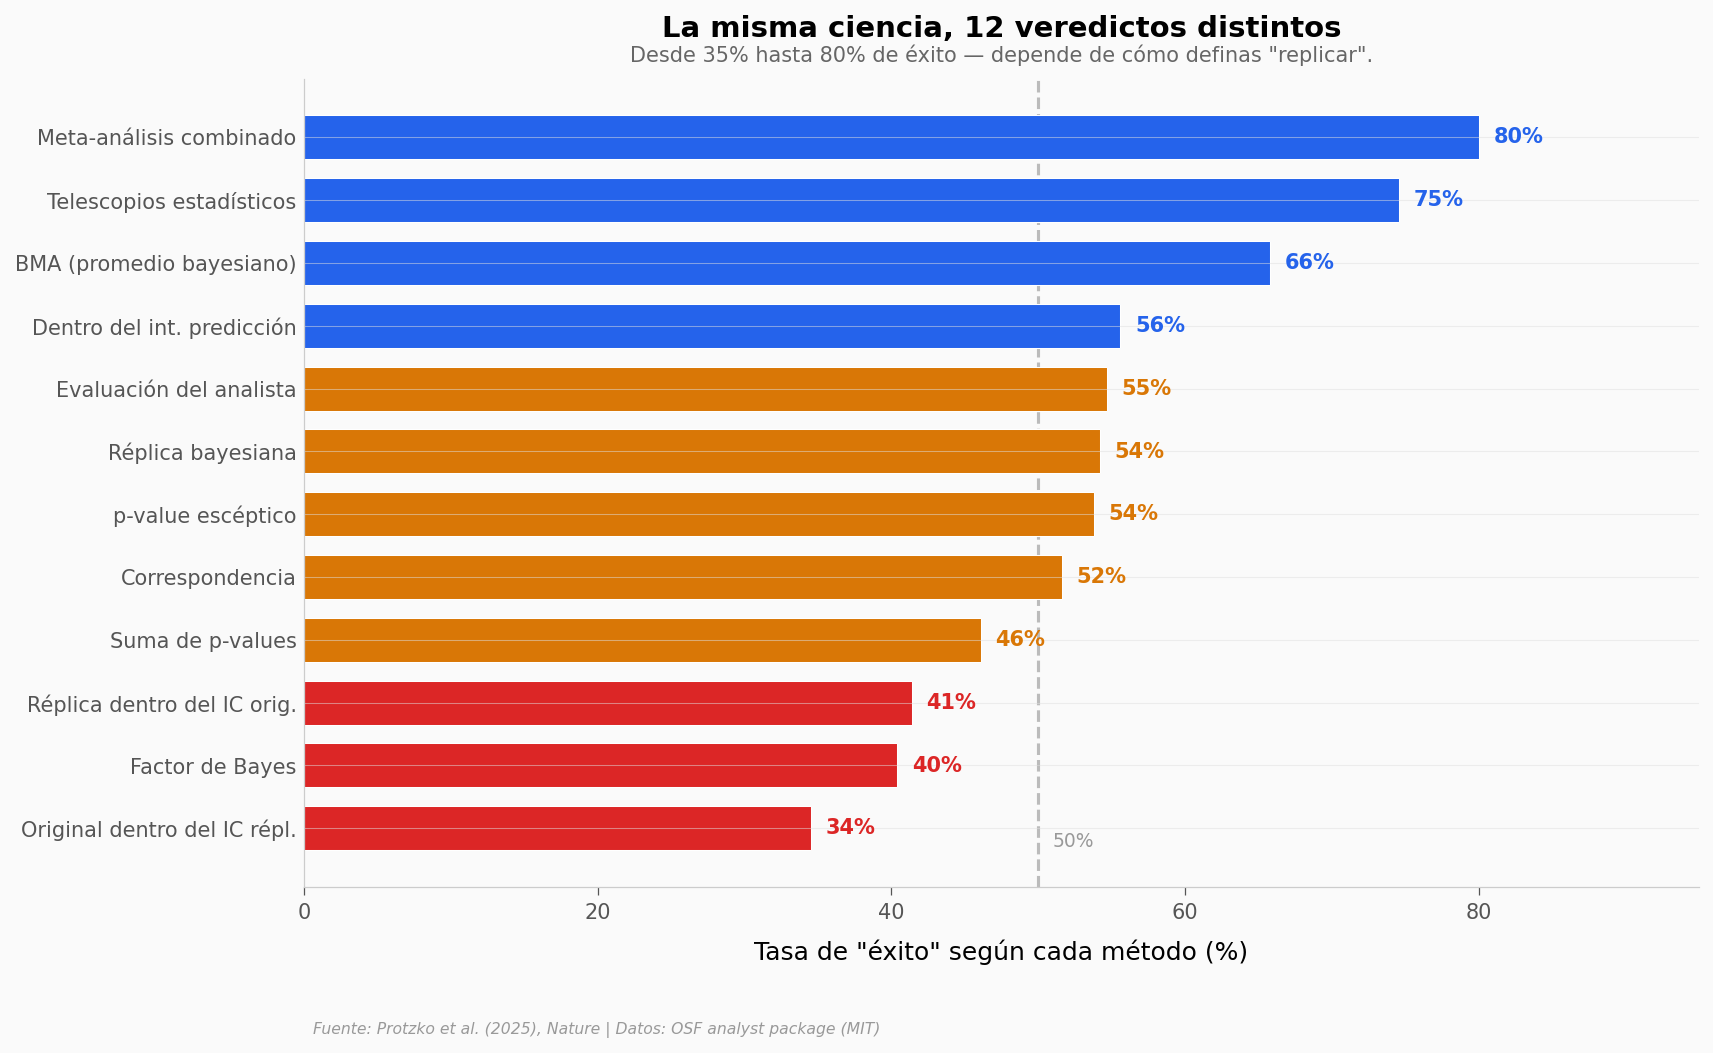

In [4]:
# 12 métodos de evaluación
df_met = metodos.sort_values('pct').copy()

# Traducción de métodos
trad_met = {
    'meta_success': 'Meta-análisis combinado',
    'telescopes': 'Telescopios estadísticos',
    'bma_result': 'BMA (promedio bayesiano)',
    'wthn_pi': 'Dentro del int. predicción',
    'analyst': 'Evaluación del analista',
    'bayes_rep': 'Réplica bayesiana',
    'skep_p': 'p-value escéptico',
    'correspondence': 'Correspondencia',
    'sum_p': 'Suma de p-values',
    'rep_wthn': 'Réplica dentro del IC orig.',
    'bf_result': 'Factor de Bayes',
    'orig_wthn': 'Original dentro del IC répl.'
}
df_met['metodo_es'] = df_met['metodo'].map(trad_met)

fig, ax = plt.subplots(figsize=(12, 7))

colores = [COLOR_REPLICADO if p >= 55 else COLOR_NO_REPLICADO if p < 45 else COLOR_REFERENCIA
           for p in df_met['pct']]

bars = ax.barh(df_met['metodo_es'], df_met['pct'],
               color=colores, edgecolor='white', linewidth=0.5, height=0.7)

for bar, (_, row) in zip(bars, df_met.iterrows()):
    x = bar.get_width()
    ax.text(x + 1, bar.get_y() + bar.get_height()/2,
            f'{row["pct"]:.0f}%', va='center', fontsize=10, fontweight='bold',
            color=bar.get_facecolor())

ax.axvline(50, color=COLOR_CONTEXTO, linewidth=1.5, linestyle='--', zorder=0)
ax.text(51, -0.3, '50%', fontsize=9, color='#999999')

ax.set_xlabel('Tasa de "éxito" según cada método (%)', fontsize=12)
ax.set_xlim(0, 95)
ax.set_title('La misma ciencia, 12 veredictos distintos',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Desde 35% hasta 80% de éxito — depende de cómo definas "replicar".',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/metodos_evaluacion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánto se encoge un efecto al replicarlo?

La tasa de replicación binaria (55%) es una simplificación. La historia real está en **cuánto se reduce el efecto**. Veamos la distribución.

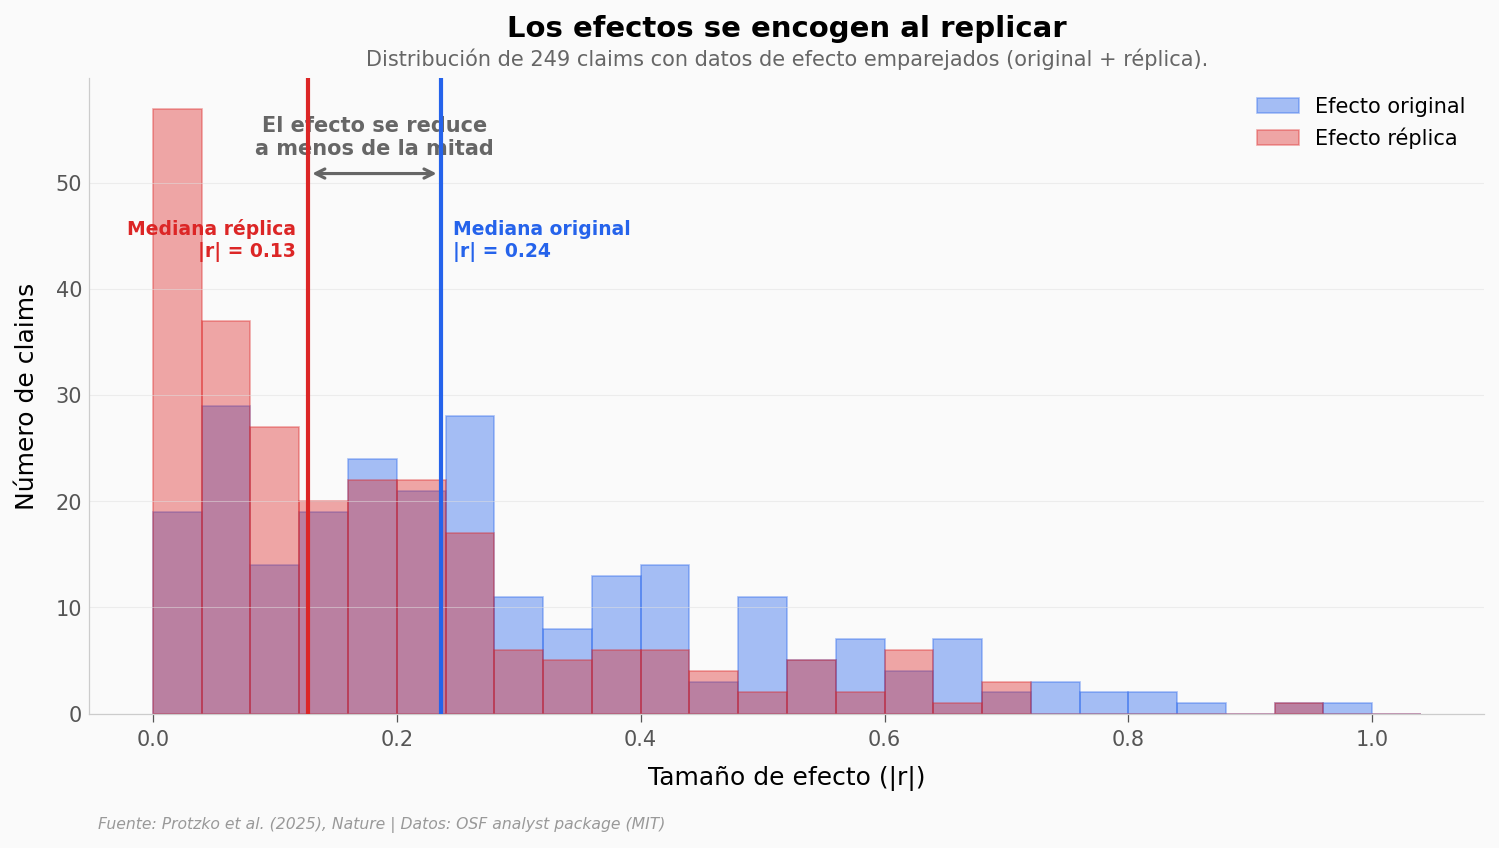

In [5]:
# Distribución de tamaños de efecto: original vs réplica
df = scatter.dropna(subset=['abs_orig_r', 'abs_repli_r']).copy()

fig, ax = plt.subplots(figsize=(12, 5.5))

bins = np.arange(0, 1.05, 0.04)

ax.hist(df['abs_orig_r'], bins=bins, color=COLOR_REPLICADO, alpha=0.4,
        edgecolor=COLOR_REPLICADO, linewidth=0.8, label='Efecto original')
ax.hist(df['abs_repli_r'], bins=bins, color=COLOR_NO_REPLICADO, alpha=0.4,
        edgecolor=COLOR_NO_REPLICADO, linewidth=0.8, label='Efecto réplica')

# Medianas
med_orig = df['abs_orig_r'].median()
med_repli = df['abs_repli_r'].median()
ymax = ax.get_ylim()[1]

ax.axvline(med_orig, color=COLOR_REPLICADO, linewidth=2, linestyle='-', zorder=5)
ax.axvline(med_repli, color=COLOR_NO_REPLICADO, linewidth=2, linestyle='-', zorder=5)

# Flecha bidireccional entre medianas
ax.annotate('', xy=(med_repli, ymax*0.85), xytext=(med_orig, ymax*0.85),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((med_orig + med_repli)/2, ymax*0.88,
        f'El efecto se reduce\na menos de la mitad',
        fontsize=10, ha='center', color='#666666', fontweight='bold')

ax.text(med_orig + 0.01, ymax*0.72, f'Mediana original\n|r| = {med_orig:.2f}',
        fontsize=9, color=COLOR_REPLICADO, fontweight='bold')
ax.text(med_repli - 0.01, ymax*0.72, f'Mediana réplica\n|r| = {med_repli:.2f}',
        fontsize=9, color=COLOR_NO_REPLICADO, fontweight='bold', ha='right')

ax.set_xlabel('Tamaño de efecto (|r|)', fontsize=12)
ax.set_ylabel('Número de claims', fontsize=12)
ax.set_title('Los efectos se encogen al replicar',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución de 249 claims con datos de efecto emparejados (original + réplica).',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_efectos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ~55% de los claims se replican | ✅ | 151/274 = 55,1% (IC 95%: 49,2–60,9%). Cross-check exacto con el paper |
| Los efectos se reducen a la mitad | ✅ | Mediana |r|: 0,24 (original) → 0,13 (réplica). Ratio de medianas = 0,54 |
| La tasa varía entre disciplinas | ✅ | Rango 42,9–71,4% (n ≥ 5 claims por campo). Educación lidera, sociología cierra |
| El resultado depende del método | ✅ | 12 métodos en datos públicos: 35%–80% de "éxito" (paper reporta 13: 29%–75%). El meta-análisis combinado es el más generoso |
| Las réplicas tenían poder suficiente | ✅ | Mediana 99,6% — no es un problema de muestra |

> **Limitaciones:** (1) Solo claims positivos (p < 0,05 original) — no sabemos la tasa base de aciertos. (2) Los campos con menos de 10 claims (criminología, salud, administración) tienen intervalos de confianza amplios. (3) Usamos `conv_r` como tamaño de efecto; la conversión desde distintas estadísticas (F, t, χ²) a Pearson r introduce ruido. (4) El paper reporta una reducción de varianza compartida del 82,4%; nuestro cálculo con `conv_r` da ~71% — la diferencia refleja que el paper usa cálculos intermedios no disponibles en el analyst package público.

---

## Ahora tú

1. **¿Los efectos grandes resisten mejor?** Corre la celda de abajo — divide los claims en terciles por tamaño de efecto original y compara tasas de replicación.

2. **¿Qué pasa si bajas la vara?** Filtra `scatter[scatter['repli_p_value'] < 0.10]` (más permisivo que 0,05). ¿Cuántos claims "se salvan" con un umbral más generoso?

3. **¿El campo importa más que el efecto?** Cruza disciplina con tamaño de efecto. ¿Los campos con peor replicación tienen efectos originales más pequeños, o es otra cosa?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Los efectos grandes resisten mejor que los pequeños?

df_exp = scatter.dropna(subset=['abs_orig_r', 'abs_repli_r']).copy()
df_exp['tercil'] = pd.qcut(df_exp['abs_orig_r'], 3, labels=['Pequeño', 'Mediano', 'Grande'])

print('═' * 55)
print('¿Los efectos grandes resisten mejor la replicación?')
print('═' * 55)
for t in ['Pequeño', 'Mediano', 'Grande']:
    sub = df_exp[df_exp['tercil'] == t]
    n_rep = sub['repli_score_criteria_met'].sum()
    n_tot = len(sub)
    pct = n_rep / n_tot * 100
    med_orig = sub['abs_orig_r'].median()
    med_repli = sub['abs_repli_r'].median()
    print(f'\n  {t:8} (|r| orig mediana = {med_orig:.2f}):')
    print(f'    Replicados: {n_rep:.0f}/{n_tot} = {pct:.1f}%')
    print(f'    |r| réplica mediana: {med_repli:.3f}')

print(f'\n→ Los efectos más grandes {"SÍ" if df_exp[df_exp["tercil"]=="Grande"]["repli_score_criteria_met"].mean() > df_exp[df_exp["tercil"]=="Pequeño"]["repli_score_criteria_met"].mean() else "NO"} se replican más que los pequeños.')

═══════════════════════════════════════════════════════
¿Los efectos grandes resisten mejor la replicación?
═══════════════════════════════════════════════════════

  Pequeño  (|r| orig mediana = 0.07):
    Replicados: 53/83 = 63.9%
    |r| réplica mediana: 0.055

  Mediano  (|r| orig mediana = 0.24):
    Replicados: 49/83 = 59.0%
    |r| réplica mediana: 0.139

  Grande   (|r| orig mediana = 0.49):
    Replicados: 40/83 = 48.2%
    |r| réplica mediana: 0.218

→ Los efectos más grandes NO se replican más que los pequeños.


---

### Créditos

- **Paper:** Protzko, J., Krosnick, J., Nelson, L.D. et al. (2025). Investigating the replicability of the social and behavioural sciences. *Nature*. DOI: [10.1038/s41586-025-10078-y](https://doi.org/10.1038/s41586-025-10078-y)
- **Datos:** [OSF Analyst package](https://doi.org/10.17605/OSF.IO/BZFGY) — archived repository (MIT License)
- **Programa:** [SCORE (Systematizing Confidence in Open Research and Evidence)](https://doi.org/10.17605/OSF.IO/DTZX4)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com) | [Repositorio](https://github.com/Ciencia-a-Mordiscos/lab)